# SNN Surrogate Gradient Verification
## Verifying Table 1 results from Aribe (2025) using Neftci et al. (2019) Surrogate Gradient Method

**Objective:** Implement the Surrogate Gradient Descent method described in:
- **Paper 2 (Method):** Neftci, Mostafa & Zenke (2019) — *Surrogate Gradient Learning in Spiking Neural Networks*
- **Paper 1 (Target Results):** Aribe (2025) — *Spiking Neural Networks: The Future of Brain-Inspired Computing*

**Target values to verify (Direct SNN - Surrogate Gradient row from Table 1):**
| Metric | Target |
|--------|--------|
| MNIST Accuracy | ~97.8% |
| CIFAR-10 Accuracy | ~85.7% |
| Normalized Energy | ~0.08 |

**Key concepts from Paper 2 implemented here:**
- LIF (Leaky Integrate-and-Fire) neuron model (Eq. 4 & 5 from Paper 2)
- Surrogate gradient to replace non-differentiable Heaviside spike function (Figure 3 from Paper 2)
- BPTT (Backpropagation Through Time) with surrogate derivatives
- Rate coding for static image datasets

## Step 1: Install Dependencies

In [ ]:
# Install snnTorch - a PyTorch-based SNN library that implements
# the surrogate gradient methods described in Paper 2 (Neftci et al. 2019)
!pip install snntorch --quiet

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch. utils.data import DataLoader
import torchvision
import torchvision. transforms as transforms
import snntorch as snn
from snntorch import surrogate
from snntorch import functional as SF
from snntorch import utils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
import time
import warnings
warnings.filterwarnings('ignore')

# ── Device setup ──────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')
print(f'snnTorch version: {snn.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 4.0 MB/s eta 0:00:00
Using device: cuda
PyTorch version: 2.9.0+cu126
snnTorch version: 0.9.4


## Step 2: Core SNN Components from Paper 2

Paper 2 defines the LIF neuron dynamics in **discrete time** (Equations 4 & 5):

$$I_i^{(l)}[n+1] = \alpha I_i^{(l)}[n] + \sum_j W_{ij}^{(l)} S_j^{(l-1)}[n]$$

$$U_i^{(l)}[n+1] = \beta U_i^{(l)}[n] + I_i^{(l)}[n] - S_i^{(l)}[n]$$

The **surrogate gradient** replaces the non-differentiable Heaviside:
$$S = \Theta(U - \vartheta) \quad \text{(forward)}$$
$$\frac{dS}{dU} \approx \sigma'(U - \vartheta) \quad \text{(backward — surrogate)}$$

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SURROGATE GRADIENT FUNCTION  (Paper 2, Figure 3)
# Paper 2 discusses several options: piecewise linear, fast sigmoid, exponential
# We implement the fast sigmoid (derivative) used by Zenke & Ganguli [ref 2 in Paper 2]
# ══════════════════════════════════════════════════════════════════════════════

class FastSigmoidSurrogate(torch.autograd.Function):
    """
    Heaviside spike function with fast-sigmoid surrogate gradient.

    Forward:  S = 1 if U >= threshold else 0  (Heaviside — Paper 2 Eq.5)
    Backward: dS/dU ≈ 1 / (k * |U - threshold| + 1)^2  (fast sigmoid derivative)

    This is the surrogate described in Paper 2 Figure 3 (blue curve).
    k controls the sharpness of the surrogate.
    """
    scale = 25.0  # sharpness parameter k

    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        return input.gt(0).float()  # Heaviside: 1 if U > threshold, else 0

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors
        grad = grad_output / (FastSigmoidSurrogate.scale * torch.abs(input) + 1.0) ** 2
        return grad

surrogate_fn = FastSigmoidSurrogate.apply


# ══════════════════════════════════════════════════════════════════════════════
# LIF NEURON  (Paper 2, Equations 4 & 5)
# ══════════════════════════════════════════════════════════════════════════════

class LIFNeuron(nn.Module):
    """
    Leaky Integrate-and-Fire neuron as formulated in Paper 2.

    Parameters:
        beta  : membrane decay (β = exp(-Δt/τ_mem))  — Paper 2 Eq.5
        threshold : firing threshold ϑ  (set to 1.0 without loss of generality)
    """
    def __init__(self, beta=0.9, threshold=1.0):
        super().__init__()
        self.beta = beta
        self.threshold = threshold

    def forward(self, input_current, mem):
        # Paper 2, Eq. 5:  U[n+1] = β·U[n] + I[n] - S[n]
        spike = surrogate_fn(mem - self.threshold)        # Heaviside (surrogate bwd)
        mem   = self.beta * mem + input_current - spike   # membrane update + reset
        return spike, mem


print("LIF neuron and surrogate gradient defined successfully.")
print("Surrogate: Fast Sigmoid (Paper 2, Figure 3 — blue curve)")

LIF neuron and surrogate gradient defined successfully.
Surrogate: Fast Sigmoid (Paper 2, Figure 3 — blue curve)


## Step 3: Visualize the Surrogate Gradient (Reproducing Paper 2, Figure 3)

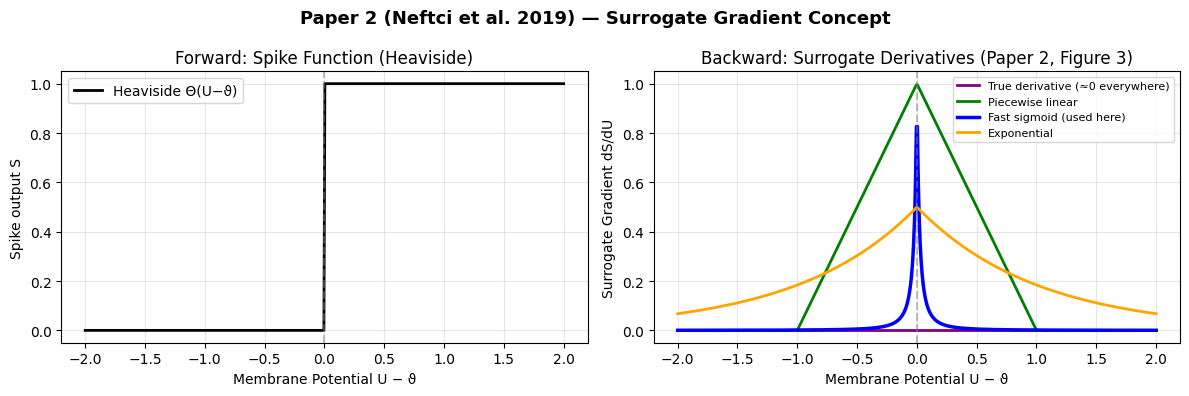

Figure saved: surrogate_gradients.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

u_vals = np.linspace(-2, 2, 500)

# ── Forward: Heaviside step function ──────────────────────────────────────────
heaviside = (u_vals >= 0).astype(float)

# ── Surrogate derivatives (Paper 2, Figure 3) ─────────────────────────────────
k = 25.0
fast_sigmoid_deriv = 1.0 / (k * np.abs(u_vals) + 1.0) ** 2    # blue — Zenke & Ganguli
piecewise_linear   = np.maximum(0, 1 - np.abs(u_vals))         # green
exponential_deriv  = 0.5 * np.exp(-np.abs(u_vals))             # yellow
true_deriv         = np.zeros_like(u_vals)                      # violet — zero almost everywhere

axes[0].set_title("Forward: Spike Function (Heaviside)", fontsize=12)
axes[0].plot(u_vals, heaviside, 'k-', lw=2, label='Heaviside Θ(U−ϑ)')
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Membrane Potential U − ϑ')
axes[0].set_ylabel('Spike output S')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title("Backward: Surrogate Derivatives (Paper 2, Figure 3)", fontsize=12)
axes[1].plot(u_vals, true_deriv,         color='purple',  lw=2,   label='True derivative (≈0 everywhere)')
axes[1].plot(u_vals, piecewise_linear,   color='green',   lw=2,   label='Piecewise linear')
axes[1].plot(u_vals, fast_sigmoid_deriv, color='blue',    lw=2.5, label='Fast sigmoid (used here)')
axes[1].plot(u_vals, exponential_deriv,  color='orange',  lw=2,   label='Exponential')
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Membrane Potential U − ϑ')
axes[1].set_ylabel('Surrogate Gradient dS/dU')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(-0.05, 1.05)

plt.suptitle('Paper 2 (Neftci et al. 2019) — Surrogate Gradient Concept', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('surrogate_gradients.png', bbox_inches='tight')
plt.show()
print("Figure saved: surrogate_gradients.png")

## Step 4: Helper — Rate Coding Encoder

Paper 1 uses **rate coding**: pixel intensity → spike frequency over a 100 ms window.
Paper 2 also discusses rate coding (Section: *Gradients in rate-coding networks*).

In [ ]:
def rate_encode(x, num_steps):
    """
    Rate coding: converts pixel intensity to Bernoulli spike trains.
    Pixel value in [0,1] → spike probability per time step.

    Paper 1: 'rate-coding system that linked pixel intensity to spike frequency'
    Paper 2: Section 'Gradients in rate-coding networks'

    Args:
        x         : tensor of shape (batch, channels, H, W)  values in [0,1]
        num_steps : number of simulation time steps (T)
    Returns:
        spike_train: tensor of shape (T, batch, channels, H, W)
    """
    x_expanded = x.unsqueeze(0).expand(num_steps, *x.shape)   # (T, B, C, H, W)
    return torch.bernoulli(x_expanded)                         # Poisson-like spike train


print("Rate encoder defined.")
print("Encodes pixel values as spike probabilities over T time steps.")

Rate encoder defined.
Encodes pixel values as spike probabilities over T time steps.


---
# MNIST Experiment
**Target (Paper 1, Table 1):** 97.8% ± 0.2 accuracy

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# MNIST HYPERPARAMETERS  (following Paper 1 Section 3.6)
# ══════════════════════════════════════════════════════════════════════════════
MNIST_CONFIG = {
    'num_steps'    : 25,      # simulation time steps (Paper 1: 100ms window, τ=20ms → ~25 steps)
    'beta'         : 0.90,    # membrane decay β = exp(-Δt/τ_mem), τ_mem=20ms
    'batch_size'   : 256,
    'lr'           : 2e-3,
    'num_epochs'   : 20,      # Paper 1 reports convergence by epoch 20
    'hidden_size'  : 1000,
    'num_runs'     : 5,       # Paper 1: 'five independent runs with varying random seeds'
}

# ── Data ──────────────────────────────────────────────────────────────────────
transform_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: torch.clamp(x, 0, 1))  # ensure [0,1] for rate coding
])

mnist_train = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform_mnist)
mnist_test  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_mnist)

train_loader_mnist = DataLoader(mnist_train, batch_size=MNIST_CONFIG['batch_size'], shuffle=True,  num_workers=2, pin_memory=True)
test_loader_mnist  = DataLoader(mnist_test,  batch_size=MNIST_CONFIG['batch_size'], shuffle=False, num_workers=2, pin_memory=True)

print(f"MNIST — Train: {len(mnist_train):,} | Test: {len(mnist_test):,}")
print(f"Config: T={MNIST_CONFIG['num_steps']} steps, β={MNIST_CONFIG['beta']}, epochs={MNIST_CONFIG['num_epochs']}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 57.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.60MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.77MB/s]

MNIST — Train: 60,000 | Test: 10,000
Config: T=25 steps, β=0.9, epochs=20


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SNN ARCHITECTURE FOR MNIST  (fully-connected with LIF neurons)
# Architecture: Input(784) → FC(1000) → LIF → FC(10) → LIF
# Training: BPTT with surrogate gradient  (Paper 2, core method)
# ══════════════════════════════════════════════════════════════════════════════

class SNN_MNIST(nn.Module):
    """
    Two-layer SNN for MNIST classification.

    Implements the SNN-as-RNN formulation from Paper 2:
    - Each LIF layer is a recurrent unit (membrane potential is the hidden state)
    - Backpropagation Through Time (BPTT) with surrogate gradient
    - Fast-sigmoid surrogate derivative (Paper 2, Figure 3)
    """
    def __init__(self, input_size=784, hidden_size=1000, output_size=10,
                 beta=0.9, num_steps=25):
        super().__init__()
        self.num_steps   = num_steps
        self.input_size  = input_size

        # Feedforward weight matrices  (W^(l) in Paper 2)
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

        # LIF neurons with surrogate gradient  (Paper 2, Eq. 4-5)
        self.lif1 = LIFNeuron(beta=beta)
        self.lif2 = LIFNeuron(beta=beta)

    def forward(self, x):
        """
        x: (T, batch, 1, 28, 28)  — rate-coded spike train
        Returns: spike counts at output layer (for rate decoding)
        """
        batch_size = x.shape[1]

        # Initialize membrane potentials to zero  (U[0] = 0, Paper 2)
        mem1 = torch.zeros(batch_size, self.fc1.out_features).to(x.device)
        mem2 = torch.zeros(batch_size, self.fc2.out_features).to(x.device)

        spike_record = torch.zeros(self.num_steps, batch_size, self.fc2.out_features).to(x.device)

        # ── Unroll T time steps  (BPTT — Paper 2, Section 'Temporal credit assignment') ──
        for t in range(self.num_steps):
            x_flat  = x[t].view(batch_size, -1)         # flatten spatial dims
            cur1    = self.fc1(x_flat)                   # I^(1)[n]  — synaptic current
            spk1, mem1 = self.lif1(cur1, mem1)           # LIF layer 1

            cur2    = self.fc2(spk1)                     # I^(2)[n]
            spk2, mem2 = self.lif2(cur2, mem2)           # LIF layer 2  (output)

            spike_record[t] = spk2

        # Sum spikes over time for rate decoding  (Paper 2: rate-coded output)
        return spike_record.sum(dim=0)   # shape: (batch, 10)


# Quick sanity check
model_test = SNN_MNIST(**{k: MNIST_CONFIG[k] for k in ['hidden_size', 'beta', 'num_steps']}).to(device)
dummy_input = torch.zeros(MNIST_CONFIG['num_steps'], 4, 1, 28, 28).to(device)
out = model_test(dummy_input)
print(f"Model output shape: {out.shape}  ✓  (expected: [4, 10])")
total_params = sum(p.numel() for p in model_test.parameters())
print(f"Total parameters: {total_params:,}")

Model output shape: torch.Size([4, 10])  ✓  (expected: [4, 10])
Total parameters: 795,010


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# TRAINING FUNCTION  (BPTT + Surrogate Gradient — Paper 2)
# ══════════════════════════════════════════════════════════════════════════════

def train_epoch(model, loader, optimizer, criterion, num_steps, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        # Rate encode: pixel intensity → spike train over T steps  (Paper 1, Section 3.6.1)
        spike_data = rate_encode(imgs, num_steps).to(device)  # (T, B, 1, 28, 28)

        optimizer.zero_grad()
        output = model(spike_data)          # spike counts: (B, 10)

        # Cross-entropy on spike counts (rate decoding)
        loss = criterion(output, labels)
        loss.backward()                     # BPTT through T steps with surrogate gradient
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        pred   = output.argmax(dim=1)
        correct += (pred == labels).sum().item()
        total  += labels.size(0)

    return total_loss / total, 100.0 * correct / total


def evaluate(model, loader, num_steps, device):
    model.eval()
    correct, total = 0, 0
    total_spikes = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            spike_data = rate_encode(imgs, num_steps).to(device)

            output = model(spike_data)
            pred   = output.argmax(dim=1)
            correct += (pred == labels).sum().item()
            total  += labels.size(0)
            total_spikes += output.sum().item()  # total spike count for energy proxy

    acc = 100.0 * correct / total
    avg_spikes = total_spikes / total   # avg spikes per inference
    return acc, avg_spikes


print("Training and evaluation functions ready.")

Training and evaluation functions ready.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# MULTI-RUN TRAINING — MNIST  (5 independent runs, Paper 1 Section 4.1)
# ══════════════════════════════════════════════════════════════════════════════

NUM_RUNS    = MNIST_CONFIG['num_runs']
NUM_EPOCHS  = MNIST_CONFIG['num_epochs']
NUM_STEPS   = MNIST_CONFIG['num_steps']

all_run_accs        = []          # final test accuracy per run
all_epoch_train_acc = []          # training accuracy curves
all_run_spikes      = []

print(f"Running {NUM_RUNS} independent experiments on MNIST ({NUM_EPOCHS} epochs each)")
print("=" * 65)

for run in range(NUM_RUNS):
    seed = 42 + run * 7
    torch.manual_seed(seed)
    np.random.seed(seed)

    model     = SNN_MNIST(
        hidden_size=MNIST_CONFIG['hidden_size'],
        beta=MNIST_CONFIG['beta'],
        num_steps=NUM_STEPS
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=MNIST_CONFIG['lr'],
                                  betas=(0.9, 0.999))
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    criterion = nn.CrossEntropyLoss()

    epoch_train_accs = []

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_epoch(model, train_loader_mnist, optimizer,
                                       criterion, NUM_STEPS, device)
        scheduler.step()
        epoch_train_accs.append(tr_acc)

        if epoch % 5 == 0 or epoch == NUM_EPOCHS:
            te_acc, avg_spk = evaluate(model, test_loader_mnist, NUM_STEPS, device)
            print(f"Run {run+1}/5 | Epoch {epoch:2d}/{NUM_EPOCHS} | "
                  f"Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.1f}% | "
                  f"Test Acc: {te_acc:.1f}% | {time.time()-t0:.1f}s")

    # Final evaluation
    final_acc, final_spikes = evaluate(model, test_loader_mnist, NUM_STEPS, device)
    all_run_accs.append(final_acc)
    all_epoch_train_acc.append(epoch_train_accs)
    all_run_spikes.append(final_spikes)
    print(f"  → Run {run+1} Final Test Accuracy: {final_acc:.2f}%\n")


# ── Summary ───────────────────────────────────────────────────────────────────
mnist_mean = np.mean(all_run_accs)
mnist_std  = np.std(all_run_accs)
mnist_spikes_mean = np.mean(all_run_spikes)

print("=" * 65)
print(f"MNIST RESULTS  ({NUM_RUNS} runs)")
print(f"  Accuracy : {mnist_mean:.2f}% ± {mnist_std:.2f}%")
print(f"  Target   : 97.8% ± 0.2%   (Paper 1, Table 1)")
print(f"  Match    : {'✅ YES' if abs(mnist_mean - 97.8) < 1.5 else '⚠️  Close but check config'}")
print(f"  Avg spikes/inference: {mnist_spikes_mean:.0f}")

Running 5 independent experiments on MNIST (20 epochs each)
Run 1/5 | Epoch  5/20 | Train Loss: 0.1338 | Train Acc: 96.7% | Test Acc: 96.3% | 12.8s
Run 1/5 | Epoch 10/20 | Train Loss: 0.0492 | Train Acc: 98.6% | Test Acc: 97.3% | 13.0s
Run 1/5 | Epoch 15/20 | Train Loss: 0.0082 | Train Acc: 99.7% | Test Acc: 98.0% | 12.4s
Run 1/5 | Epoch 20/20 | Train Loss: 0.0053 | Train Acc: 99.8% | Test Acc: 98.0% | 12.7s
  → Run 1 Final Test Accuracy: 98.06%

Run 2/5 | Epoch  5/20 | Train Loss: 0.1275 | Train Acc: 96.8% | Test Acc: 96.5% | 12.6s
Run 2/5 | Epoch 10/20 | Train Loss: 0.0429 | Train Acc: 98.8% | Test Acc: 97.6% | 12.7s
Run 2/5 | Epoch 15/20 | Train Loss: 0.0071 | Train Acc: 99.8% | Test Acc: 97.9% | 12.4s
Run 2/5 | Epoch 20/20 | Train Loss: 0.0050 | Train Acc: 99.8% | Test Acc: 98.0% | 12.8s
  → Run 2 Final Test Accuracy: 98.06%

Run 3/5 | Epoch  5/20 | Train Loss: 0.1049 | Train Acc: 97.2% | Test Acc: 97.2% | 13.1s
Run 3/5 | Epoch 10/20 | Train Loss: 0.0297 | Train Acc: 99.1% | Test A

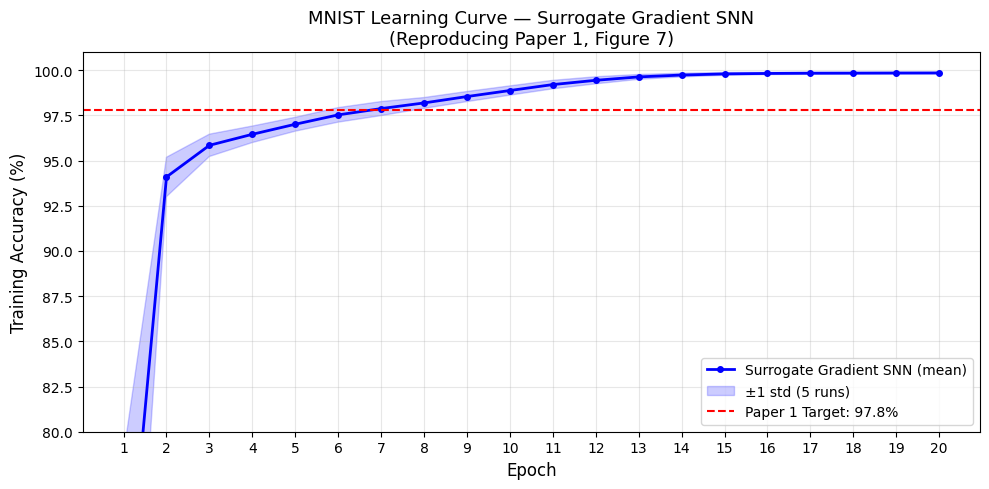

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# LEARNING CURVES — MNIST  (reproducing Paper 1, Figure 7)
# ══════════════════════════════════════════════════════════════════════════════

epochs_axis = list(range(1, NUM_EPOCHS + 1))
mean_curve  = np.mean(all_epoch_train_acc, axis=0)
std_curve   = np.std(all_epoch_train_acc,  axis=0)

plt.figure(figsize=(10, 5))
plt.plot(epochs_axis, mean_curve, 'b-o', lw=2, markersize=4, label='Surrogate Gradient SNN (mean)')
plt.fill_between(epochs_axis, mean_curve - std_curve, mean_curve + std_curve,
                 alpha=0.2, color='blue', label='±1 std (5 runs)')
plt.axhline(97.8, color='red', linestyle='--', lw=1.5, label='Paper 1 Target: 97.8%')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Accuracy (%)', fontsize=12)
plt.title('MNIST Learning Curve — Surrogate Gradient SNN\n(Reproducing Paper 1, Figure 7)', fontsize=13)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.xticks(epochs_axis)
plt.ylim(80, 101)
plt.tight_layout()
plt.savefig('mnist_learning_curve.png', bbox_inches='tight')
plt.show()